In [46]:
# Imports 

import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, norm
from matplotlib import pyplot as plt
import time

In [6]:
# Directories and Global Variables
DATA_DIRECTORY = "./results"

# Retreive all Directories and files in the results 
QUALITY_DIRECTORIES = os.listdir(DATA_DIRECTORY)

In [7]:
files = []
for q in QUALITY_DIRECTORIES: 
    runs = os.listdir(f"{DATA_DIRECTORY}/{q}")
    for f in runs: 
        files.append(f"{q}/{f}")
files

['q480/run_04.csv', 'q480/run_02.csv', 'q2160/run_03.csv', 'q2160/run_01.csv']

In [8]:
example = pd.read_csv(f"{DATA_DIRECTORY}/{files[0]}")[['Time', 'SYSTEM_POWER (Watts)']]
first_time = example['Time'].iloc[0]
example['Time'] = example['Time'].apply(lambda x: (x - first_time) / 1000)
example.head(10)

,Time,SYSTEM_POWER (Watts)
0,0.000,3.797520
1,0.001,3.797520
2,0.206,3.797520
3,0.411,3.797520
4,0.612,3.797520
5,0.817,3.797520
6,1.022,4.262172
7,1.223,4.262172
8,1.425,4.262172
9,1.626,4.262172


In [9]:
# Check whether Data is normal

stats, p_val = shapiro(example['SYSTEM_POWER (Watts)'])

print(f"With p-val {p_val}, the data is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}")

With p-val 1.7835891468272814e-07, the data is NOT NORMAL


In [10]:
# Normalising the data

mean = example['SYSTEM_POWER (Watts)'].mean()
std = example['SYSTEM_POWER (Watts)'].std()
outlier = []
max_diff = 0
print(f"std: {3 * std}")
for idx, val in enumerate(example['SYSTEM_POWER (Watts)']): 
    diff = mean - val
    if np.abs(diff) > max_diff: max_diff = np.abs(diff) 
    if np.abs(diff) > 3*std: 
        print(f"Found outlier at {idx}")
        outlier.append(idx)

print(max_diff)
normalised_example = example.drop(index=outlier) 
normalised_example   


std: 0.5010195354052136
0.4397309239094076


,Time,SYSTEM_POWER (Watts)
0,0.000,3.797520
1,0.001,3.797520
2,0.206,3.797520
3,0.411,3.797520
4,0.612,3.797520
5,0.817,3.797520
6,1.022,4.262172
7,1.223,4.262172
8,1.425,4.262172
9,1.626,4.262172


Text(0, 0.5, 'System Power measurement (Watts)')

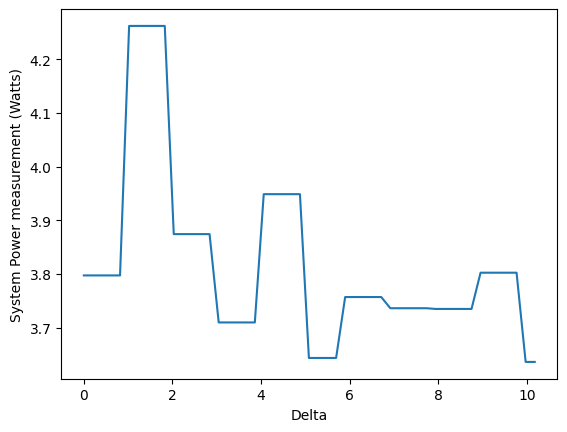

In [11]:
#Plotting data distribution
plt.plot(example['Time'], example['SYSTEM_POWER (Watts)'])
plt.xlabel("Delta")
plt.ylabel("System Power measurement (Watts)")

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7fe7c66e1910>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fe7c66e7740>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fe7c66fc860>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fe7c66fcf20>}

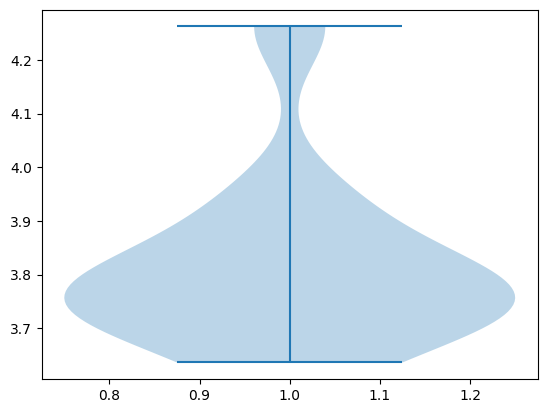

In [12]:
# Violin plots

plt.violinplot(example['SYSTEM_POWER (Watts)'])


### Creating a general setup to create combinations by subcategories 

The outlier removal didn't work, possibly becasue there are not enough sample. Might have to do something else. 

In [14]:
dataframes = {}
for f in files: 
    print(f"======== Converting file '{f}' ========")
    df = pd.read_csv(f"{DATA_DIRECTORY}/{f}")[['Time', 'SYSTEM_POWER (Watts)']]
    first_time = df['Time'].iloc[0]
    df['Time'] = df['Time'].apply(lambda x: (x - first_time) / 1000)
    dataframes[f] = df
    
dataframes[f]

======== Converting file 'q480/run_04.csv' ========
======== Converting file 'q480/run_02.csv' ========
======== Converting file 'q2160/run_03.csv' ========
======== Converting file 'q2160/run_01.csv' ========


,Time,SYSTEM_POWER (Watts)
0,0.000,19.396793
1,0.000,19.396793
2,0.201,19.396793
3,0.406,19.396793
4,0.609,19.396793
5,0.814,19.396793
6,1.018,18.857800
7,1.223,18.857800
8,1.426,18.857800
9,1.631,18.857800


In [17]:
for f, df in dataframes.items():
    stats, p_val = shapiro(df['SYSTEM_POWER (Watts)'])

    print(f"With p-val {p_val}, the data in {f} is {'NOT NORMAL' if p_val < 0.05 else 'NORMAL'}\n==============================================================")

With p-val 1.7835891468272814e-07, the data in q480/run_04.csv is NOT NORMAL
With p-val 4.613852389634653e-07, the data in q480/run_02.csv is NOT NORMAL
With p-val 2.0969023274320573e-07, the data in q2160/run_03.csv is NOT NORMAL
With p-val 0.0024541314983051073, the data in q2160/run_01.csv is NOT NORMAL


In [19]:
normalised_dataframes = {}
for f, df in dataframes.items(): 
    mean = df['SYSTEM_POWER (Watts)'].mean()
    std = df['SYSTEM_POWER (Watts)'].std()
    outlier = []
    max_diff = 0
    print(f"3x std: {3 * std} | mean: {mean}")
    for idx, val in enumerate(df['SYSTEM_POWER (Watts)']): 
        diff = mean - val
        abs = np.abs(diff)
        if abs > max_diff: max_diff = abs
        if abs > 3*std: 
            print(f"Found outlier at {idx}")
            outlier.append(idx)

    print(f"Maximum difference found: {max_diff}")
    n_df = df.drop(index=outlier) 
    normalised_dataframes[f] = n_df
    print("===============================================")

3x std: 0.5010195354052136 | mean: 3.8224412982280436
Maximum difference found: 0.4397309239094076
3x std: 1.0619900265089248 | mean: 4.1347908194248495
Maximum difference found: 1.0475588624293986
3x std: 1.3323922868556861 | mean: 18.6368418674843
Maximum difference found: 0.8334874171836688
3x std: 1.4152552859761796 | mean: 18.63091053682215
Maximum difference found: 0.7658828286563697


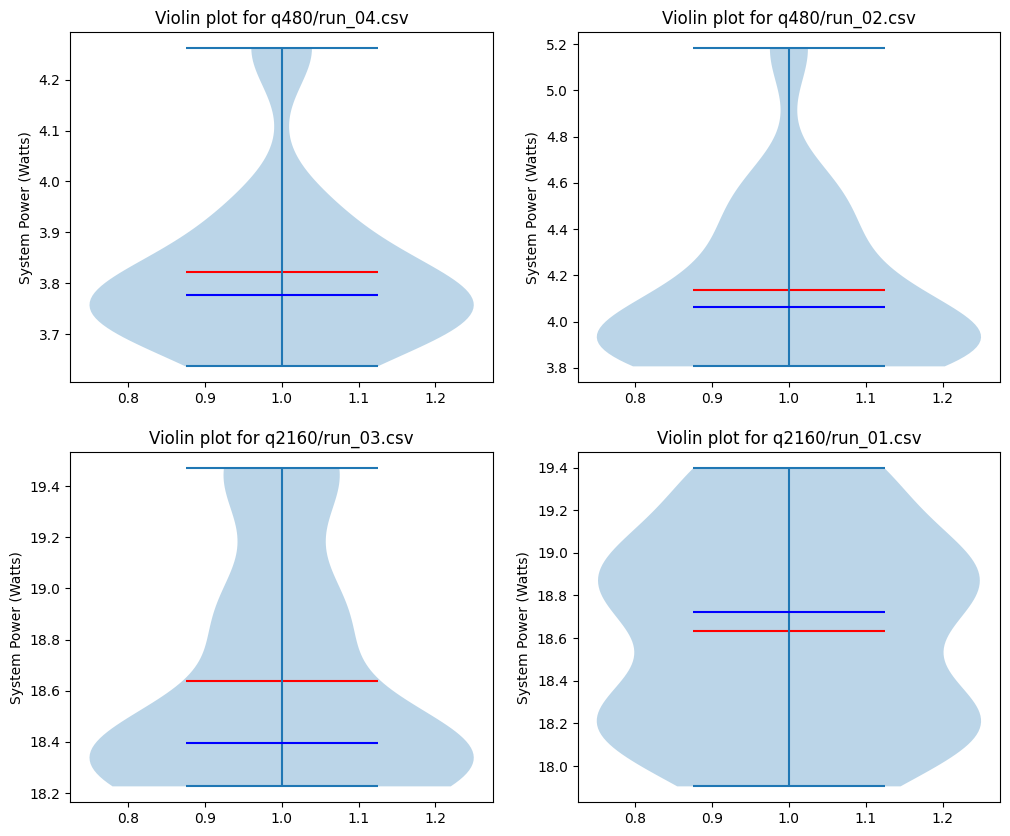

In [36]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    parts = ax.violinplot(df['SYSTEM_POWER (Watts)'], showmeans=True, showmedians=True)
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')    

plt.show()

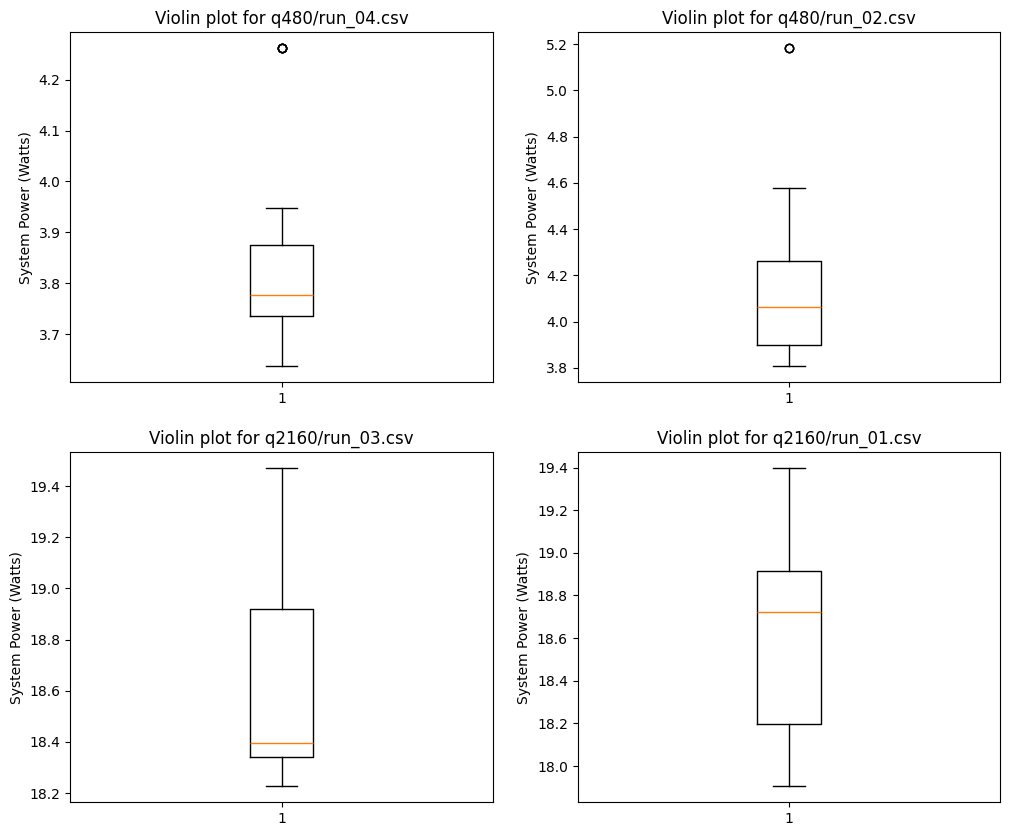

In [37]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_ylabel('System Power (Watts)')
    ax.boxplot(df['SYSTEM_POWER (Watts)'])

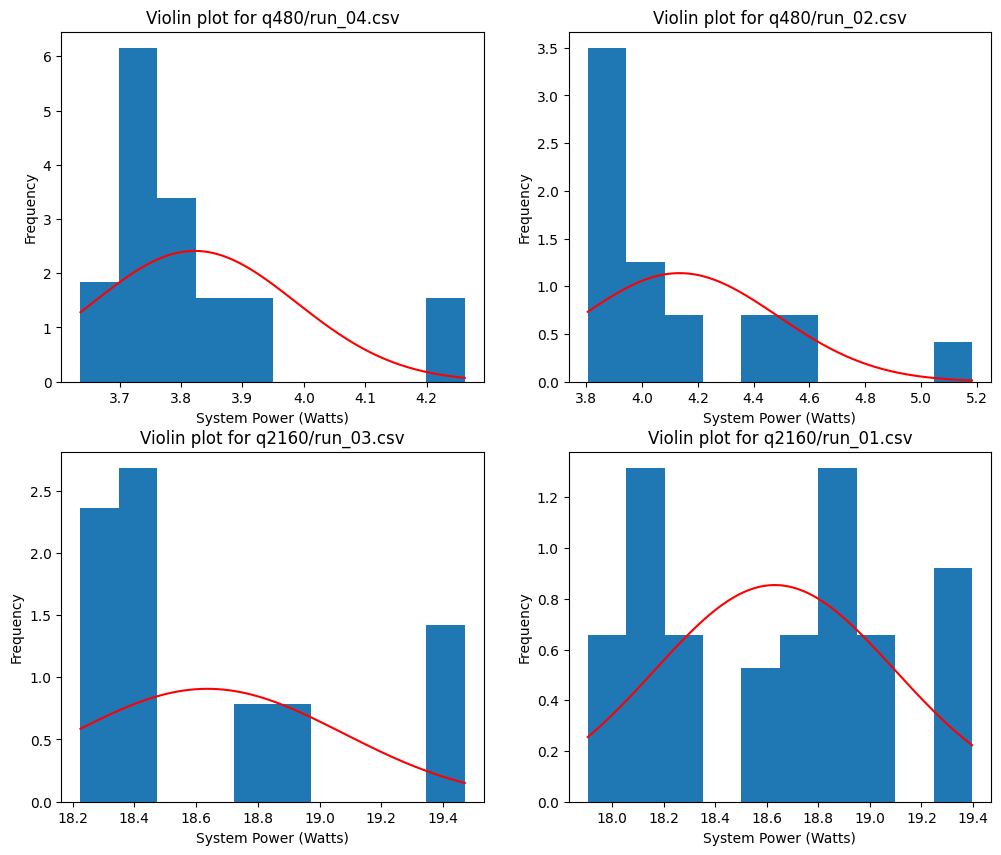

In [56]:
fig, plots = plt.subplots(nrows = len(QUALITY_DIRECTORIES), 
                               ncols = len(os.listdir(f"{DATA_DIRECTORY}/{QUALITY_DIRECTORIES[0]}")),
                               figsize =(12, 10))
plots = plots.flatten()

for idx, (f, df) in enumerate(normalised_dataframes.items()): 
    ax = plots[idx]
    ax.set_title(f"Violin plot for {f}")
    ax.set_xlabel('System Power (Watts)')
    ax.set_ylabel('Frequency')
    ax.hist(df['SYSTEM_POWER (Watts)'], density=True)
    mu, std = norm.fit(df['SYSTEM_POWER (Watts)'])
    x = np.linspace(df['SYSTEM_POWER (Watts)'].min(), df['SYSTEM_POWER (Watts)'].max(), 200)
    p = norm.pdf(x, mu, std)
    
    ax.plot(x, p, 'r')